# 마법학교 축제 간식 판매 분석 — Bar 그래프 기초

마법학교 축제가 끝났습니다. 학생회는 다음 축제에서 어떤 간식을 더 준비할지 결정하려고 합니다. 7가지 간식의 판매량을 막대그래프로 비교하며 `plt.bar()`의 기본 사용법을 익혀 봅시다.

## 학습 목표

- 막대그래프가 **항목별 크기 비교**에 적합한 이유를 이해한다.
- `plt.bar()`와 `plt.barh()`로 세로·가로 막대그래프를 그린다.
- 최댓값, 최솟값, 정렬, 조건 필터링을 간단히 연습한다.
- 그래프를 보고 축제 판매량에 관한 인사이트를 찾는다.

> 객관식 채점이 가능한 미션과 관찰 미션을 분리했습니다. 정답이 필요한 미션에는 정답 코드와 예상 출력이 모두 들어 있습니다.


## 0. 실습 준비

먼저 함께 제공된 `magic_school_snacks.csv` 파일을 Colab에 업로드하세요.


In [1]:
!pip install -q koreanize-matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from google.colab import files

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.unicode_minus'] = False

Saving magic_school_snacks.csv to magic_school_snacks.csv


,간식코드,간식이름,종류,판매개수
0,1,별빛 마카롱,디저트,42
1,2,구름 솜사탕,디저트,35
2,3,달토끼 쿠키,디저트,58
3,4,용암 핫도그,식사,27
4,5,무지개 젤리,디저트,46
5,6,마법 콜라,음료,31
6,7,드래곤 팝콘,간식,51


## 데이터 살펴보기

| 컬럼 | 의미 |
|---|---|
| 간식코드 | 온라인저지 답안에 사용할 간식 번호 |
| 간식이름 | 축제에서 판매한 간식 이름 |
| 종류 | 디저트·식사·음료·간식 구분 |
| 판매개수 | 축제에서 판매된 수량 |


In [3]:
print(df.shape)
print(df.info())
df

(7, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   간식코드    7 non-null      int64 
 1   간식이름    7 non-null      object
 2   종류      7 non-null      object
 3   판매개수    7 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 356.0+ bytes
None


,간식코드,간식이름,종류,판매개수
0,1,별빛 마카롱,디저트,42
1,2,구름 솜사탕,디저트,35
2,3,달토끼 쿠키,디저트,58
3,4,용암 핫도그,식사,27
4,5,무지개 젤리,디저트,46
5,6,마법 콜라,음료,31
6,7,드래곤 팝콘,간식,51


# Mission 1 — 간식은 모두 몇 종류일까? `[정답형]`

데이터에 기록된 간식의 개수를 구하세요.

**답안 형식:** 정수 1개


In [4]:
# 정답 코드
answer = len(df)
print(answer)

7


**예상 출력**

```text
7
```


# Mission 2 — 첫 번째 막대그래프 그리기 `[관찰형]`

간식별 판매개수를 세로 막대그래프로 그려 보세요.

그래프를 본 뒤 다음을 자유롭게 기록해 봅시다.

- 가장 높아 보이는 막대는 어떤 간식인가요?
- 막대그래프는 선그래프보다 항목별 판매량 비교가 쉬운가요?

> 이 미션은 개인의 관찰을 적는 활동이므로 온라인저지 문제로 사용하지 않습니다.


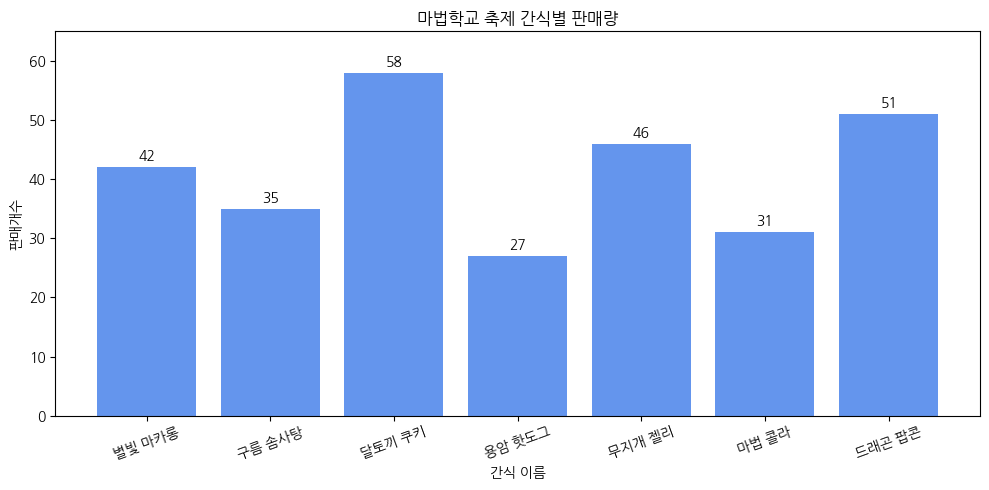

In [5]:
# 완성 코드
plt.figure(figsize=(10, 5))
bars = plt.bar(df['간식이름'], df['판매개수'], color='cornflowerblue')

plt.title('마법학교 축제 간식별 판매량')
plt.xlabel('간식 이름')
plt.ylabel('판매개수')
plt.xticks(rotation=20)
plt.bar_label(bars, padding=3)
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

# Mission 3 — 가장 많이 팔린 간식 찾기 `[정답형]`

판매개수가 가장 많은 간식의 **간식코드**와 **판매개수**를 구하세요.

**답안 형식:** 간식코드와 판매개수를 한 줄씩 출력


In [6]:
# 정답 코드
best_index = df['판매개수'].idxmax()
best_code = int(df.loc[best_index, '간식코드'])
best_sales = int(df.loc[best_index, '판매개수'])

print(best_code)
print(best_sales)

3
58


**예상 출력**

```text
3
58
```


# Mission 4 — 가장 적게 팔린 간식과 판매량 차이 `[정답형]`

1. 판매개수가 가장 적은 간식의 **간식코드**를 구하세요.
2. 가장 많은 판매개수와 가장 적은 판매개수의 차이를 구하세요.

**답안 형식:** 간식코드와 차이를 한 줄씩 출력


In [7]:
# 정답 코드
worst_index = df['판매개수'].idxmin()
worst_code = int(df.loc[worst_index, '간식코드'])
sales_gap = int(df['판매개수'].max() - df['판매개수'].min())

print(worst_code)
print(sales_gap)

4
31


**예상 출력**

```text
4
31
```


# Mission 5 — 판매량 순서로 정렬하기 `[정답형]`

판매개수가 많은 순서로 데이터를 정렬하고 가로 막대그래프를 그리세요. 그다음 판매량 상위 3개 간식의 **간식코드**를 순서대로 출력하세요.

**답안 형식:** 간식코드 3개를 한 줄씩 출력


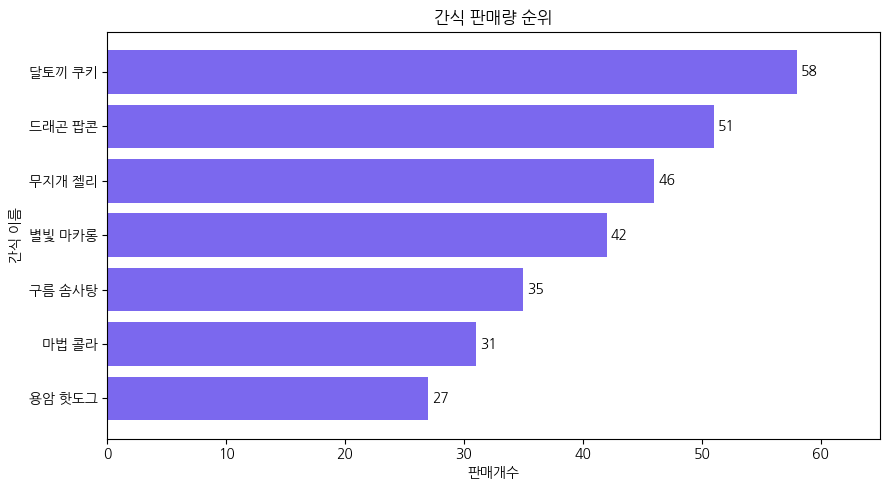

3
7
5


In [8]:
# 정답 코드
ranked = df.sort_values('판매개수', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(ranked['간식이름'], ranked['판매개수'], color='mediumslateblue')
plt.gca().invert_yaxis()
plt.title('간식 판매량 순위')
plt.xlabel('판매개수')
plt.ylabel('간식 이름')
plt.bar_label(bars, padding=3)
plt.xlim(0, 65)
plt.tight_layout()
plt.show()

top3_codes = ranked.head(3)['간식코드']
for code_value in top3_codes:
    print(int(code_value))

**예상 출력**

```text
3
7
5
```


# Mission 6 — 40개 이상 팔린 간식 표시하기 `[정답형]`

판매개수가 40개 이상인 간식은 몇 종류인지 구하세요. 이어서 40개 이상 팔린 간식은 초록색, 나머지는 연한 회색으로 표시한 막대그래프를 그리세요.

**답안 형식:** 정수 1개

> 마지막 미션은 복잡한 계산 없이 조건식과 색상 지정만 복습합니다.


4


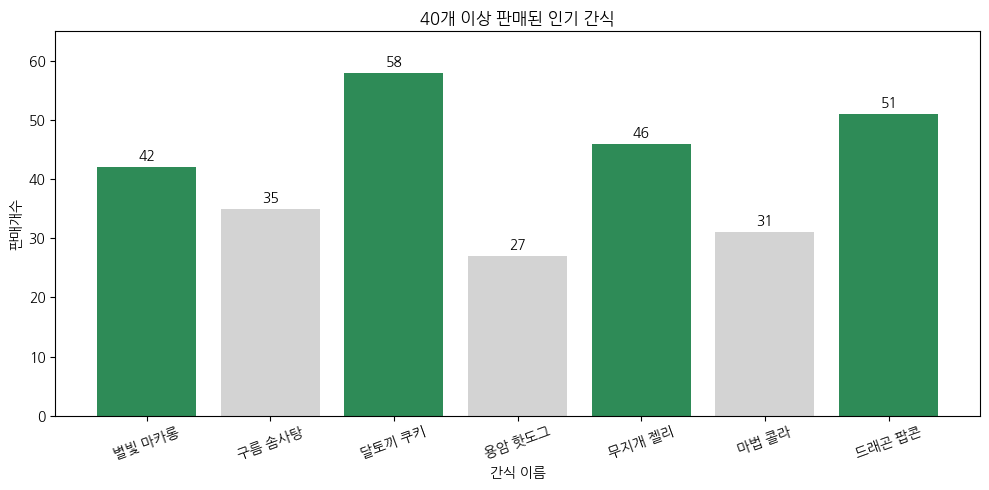

In [9]:
# 정답 코드
popular = df['판매개수'] >= 40
answer = int(popular.sum())
print(answer)

colors = ['seagreen' if value >= 40 else 'lightgray'
          for value in df['판매개수']]

plt.figure(figsize=(10, 5))
bars = plt.bar(df['간식이름'], df['판매개수'], color=colors)
plt.title('40개 이상 판매된 인기 간식')
plt.xlabel('간식 이름')
plt.ylabel('판매개수')
plt.xticks(rotation=20)
plt.bar_label(bars, padding=3)
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

**예상 출력**

```text
4
```


# 분석 결과 정리

- 가장 많이 팔린 간식은 **달토끼 쿠키(58개)**입니다.
- 가장 적게 팔린 간식은 **용암 핫도그(27개)**입니다.
- 최고 판매량과 최저 판매량의 차이는 **31개**입니다.
- 40개 이상 팔린 간식은 **4종류**입니다.
- 판매량 상위 3개 간식코드는 **3, 7, 5**입니다.

## 발견할 수 있는 인사이트

다음 축제의 준비 수량을 정할 때 달토끼 쿠키와 드래곤 팝콘을 우선 검토할 수 있습니다. 반면 용암 핫도그는 준비 수량이나 판매 방식을 다시 살펴볼 필요가 있습니다.

다만 이 데이터에는 **가격, 원가, 재고, 만족도**가 없습니다. 따라서 판매개수만으로 “가장 이익이 큰 간식”이나 “왜 잘 팔렸는지”까지 단정할 수는 없습니다.


# Bar 그래프 핵심 문법

```python
# 세로 막대그래프
plt.bar(x, height)

# 가로 막대그래프
plt.barh(y, width)

# 막대 위에 값 표시
bars = plt.bar(x, height)
plt.bar_label(bars)

# 조건에 따라 색상 바꾸기
colors = ['green' if value >= 40 else 'lightgray' for value in values]
plt.bar(x, values, color=colors)
```

막대그래프는 **서로 다른 항목의 크기**를 비교할 때 사용합니다. 시간의 흐름에 따른 연속적인 변화는 선그래프가 더 잘 어울립니다.
